In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

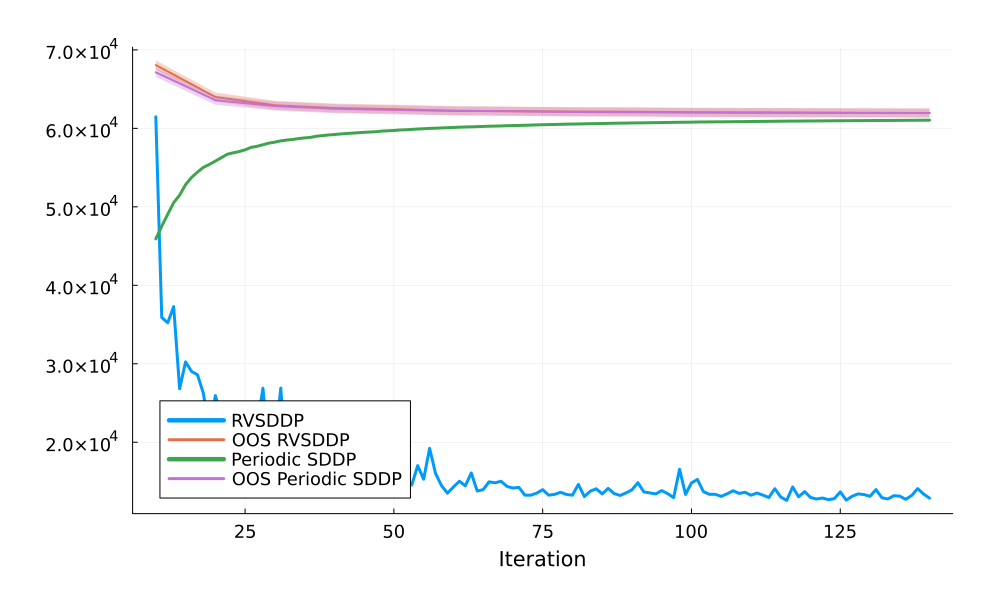

In [112]:
results = Dict()
seed_list = 1:8
iter_max = 141
iter_list_value = 10:140
iter_list_oos = 10:10:140
shift_list = [RVSDDP.no_shift, RVSDDP.shift_update_random_forward]
# shift_list = [RVSDDP.no_shift]
discount_factor=0.8
period = 12
N=15000
TimeHorizon = 12*(1+Int(round(log(0.001)/(12*log(discount_factor)))))
for seed in seed_list
    for shift in shift_list
        folder = "results_msppy/$(shift)/$(discount_factor)/seed_$(seed)_iter_$(iter_max)" 
        df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
        approx_values = df_approx_values[1:end, :approx_value]
        df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
        deltas = [df_deltas[df_deltas[:, :node] .== t, :delta] for t in 1:period]
        hat_delta = [RVSDDP.compute_hat_delta(deltas, period, 12, iter, discount_factor) for iter in 1:iter_max]
        oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(iter)_$(TimeHorizon)_$N.csv"), DataFrame) for iter in iter_list_oos]
        oos_mean = [mean(oos_df[i][1:end, :oos_horizon]) for i in 1:length(oos_df)]
        oos_std = [std(oos_df[i][1:end, :oos_horizon]) for i in 1:length(oos_df)]
        results[(seed, shift)] = (approx_values, hat_delta, oos_mean, oos_std)
    end
end

results_mean = Dict()
for shift in shift_list
    all_approx_values = [results[(seed, shift)][1][iter_list_value] for seed in seed_list]
    all_hat_delta = [results[(seed, shift)][2][iter_list_value] for seed in seed_list]
    all_oos_mean = [results[(seed, shift)][3] for seed in seed_list]
    all_oos_std = [results[(seed, shift)][4] for seed in seed_list]
    oos_mean_matrix = hcat(all_oos_mean...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    oos_std_matrix = hcat(all_oos_std...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    
    # Stack them into matrices for quantile computation
    approx_values_matrix = hcat(all_approx_values...)  # 100 x 10 matrix
    hat_delta_matrix = hcat(all_hat_delta...)  # 100 x 10 matrix
    
    # Compute quantiles (20%-80%) across seeds for each iteration
    approx_values_20 = [quantile(approx_values_matrix[iter, :], 0.2) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_80 = [quantile(approx_values_matrix[iter, :], 0.8) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_mean = mean(approx_values_matrix, dims=2)[:]
    
    hat_delta_20 = [quantile(hat_delta_matrix[iter, :], 0.2) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_80 = [quantile(hat_delta_matrix[iter, :], 0.8) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_mean = mean(hat_delta_matrix, dims=2)[:]

    oos_mean = mean(oos_mean_matrix, dims=2)[:]
    oos_std = mean(oos_std_matrix, dims=2)[:]

    results_mean[shift] = (approx_values_20, approx_values_80, hat_delta_20, hat_delta_80, approx_values_mean, hat_delta_mean, oos_mean, oos_std)
end

tcrit = quantile(TDist(N-1), 0.975)

rvsddp_value = 0*results_mean[RVSDDP.shift_update_random_forward][5] + results_mean[RVSDDP.shift_update_random_forward][6]

oos_rvsddp_value = results_mean[RVSDDP.shift_update_random_forward][7]
oos_rvsddp_lower = results_mean[RVSDDP.shift_update_random_forward][7] - tcrit * results_mean[RVSDDP.shift_update_random_forward][8] / sqrt(1*N)
oos_rvsddp_upper = results_mean[RVSDDP.shift_update_random_forward][7] + tcrit * results_mean[RVSDDP.shift_update_random_forward][8] / sqrt(1*N)

periodic_value = results_mean[RVSDDP.no_shift][5]
periodic_lower = results_mean[RVSDDP.no_shift][1]
periodic_upper = results_mean[RVSDDP.no_shift][2]

oos_periodic_value = results_mean[RVSDDP.no_shift][7]
oos_periodic_lower = results_mean[RVSDDP.no_shift][7] - tcrit * results_mean[RVSDDP.no_shift][8] / sqrt(1*N)
oos_periodic_upper = results_mean[RVSDDP.no_shift][7] + tcrit * results_mean[RVSDDP.no_shift][8] / sqrt(1*N)

# p = plot(iter_list, rvsddp_value, label="RVSDDP", linewidth=3, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600),
#      margin=10Plots.mm)
# plot!(iter_list, periodic_value,
#       label="Periodic SDDP", linewidth=3)
# xlabel!("Iteration")
plot(iter_list_value, rvsddp_value, label="RVSDDP", linewidth=3, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600),
     margin=10Plots.mm)
# plot!(iter_list_oos, oos_periodic_value,
#       label="Cost simulation Periodic SDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=2)
plot!(iter_list_oos, oos_rvsddp_value,
      ribbon=(oos_rvsddp_value - oos_rvsddp_lower, oos_rvsddp_upper - oos_rvsddp_value),
      label="OOS RVSDDP", linewidth=2, fillalpha=0.3)
plot!(iter_list_value, periodic_value, label="Periodic SDDP", linewidth=3, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600),
     margin=10Plots.mm)
# plot!(iter_list_oos, oos_periodic_value,
#       label="Cost simulation Periodic SDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=2)
plot!(iter_list_oos, oos_periodic_value,
      ribbon=(oos_periodic_value - oos_periodic_lower, oos_periodic_upper - oos_periodic_value),
      label="OOS Periodic SDDP", linewidth=2, fillalpha=0.3)
xlabel!("Iteration")
# savefig(p, "results_msppy/plot_$discount_factor.png")

In [110]:
(100*tcrit*results_mean[RVSDDP.no_shift][8][end]/results_mean[RVSDDP.no_shift][5][end])^2

3479.7980430652874